# ECB Shock Regressions

This notebook keeps the same underlying shock and duration inputs, but refactors the regression workflow for readability, comparability, and compact thesis-ready output tables.

## 0. Variable Naming (Short Guide)

Dependent variables:
- `AR_0`: event-day abnormal return
- `AR_0_1`: event-day plus next-day abnormal return
- `AR_m1_1`: placebo window from previous day to next day (if available)

Shock variables:
- `ShockMP`: monetary-policy shock (`MP_pm`)
- `ShockInfo`: information shock (`CBI_pm`)

Duration variables:
- `Duration_Macaulay_std`
- `Duration_NetPayout_std`

Controls (if available and standardized):
- `beta_std`
- `log_mcap_std`
- `leverage_std`
- `bm_std`

## 1. Load data

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from plot_style import COLORS, set_global_plot_style, style_axes, style_legend, style_time_axis

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

BASE_DIR = Path('/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data')
DATA_DIR = BASE_DIR / 'intermediate'
TABLE_DIR = BASE_DIR / 'tables'
GRAPH_DIR = BASE_DIR / 'graphs'

RET_PATH = DATA_DIR / 'euro500_daily_returns.parquet'
SHOCK_PATH = DATA_DIR / 'shocks_ecb_mpd_me_d.csv'
DUR_MAC_PATH = DATA_DIR / 'EQDuration_Macaulay.parquet'
DUR_NP_PATH = DATA_DIR / 'EQDuration_Netpayout.parquet'

for p in [RET_PATH, SHOCK_PATH, DUR_MAC_PATH, DUR_NP_PATH]:
    if not p.exists():
        raise FileNotFoundError(f'Missing required input: {p}')

df_ret = pd.read_parquet(RET_PATH)
df_shock = pd.read_csv(SHOCK_PATH)
df_mac = pd.read_parquet(DUR_MAC_PATH)
df_np = pd.read_parquet(DUR_NP_PATH)

print('Loaded shapes:')
print('returns   :', df_ret.shape)
print('shocks    :', df_shock.shape)
print('macaulay  :', df_mac.shape)
print('netpayout :', df_np.shape)

set_global_plot_style()


Loaded shapes:
returns   : (3457796, 13)
shocks    : (312, 7)
macaulay  : (56500, 32)
netpayout : (54000, 55)


## 2. Prepare event panel

In [2]:
def first_existing(df, candidates, required=False, label='column'):
    col = next((c for c in candidates if c in df.columns), None)
    if required and col is None:
        raise KeyError(f'Missing {label}. Tried: {candidates}')
    return col

def merge_last_available_feature(events, features, value_col, event_date_col='date', feature_date_col='asof_effective_date', key_priority=('RIC', 'firm_id')):
    key = next((k for k in key_priority if k in events.columns and k in features.columns), None)
    if key is None:
        raise ValueError(f'No common merge key for {value_col}. Tried {key_priority}')

    left = events.copy()
    left[event_date_col] = pd.to_datetime(left[event_date_col], errors='coerce').dt.normalize()
    left['_row_order'] = np.arange(len(left))

    right = features[[key, feature_date_col, value_col]].copy()
    right[feature_date_col] = pd.to_datetime(right[feature_date_col], errors='coerce').dt.normalize()

    valid_left = left[event_date_col].notna() & left[key].notna()
    valid_right = right[feature_date_col].notna() & right[key].notna() & right[value_col].notna()
    l_ok = left.loc[valid_left].copy()
    r_ok = right.loc[valid_right].copy()

    if l_ok.empty or r_ok.empty:
        left[value_col] = np.nan
        return left.drop(columns=['_row_order']), key

    chunks = []
    for k_val, l_grp in l_ok.groupby(key, sort=False):
        r_grp = r_ok[r_ok[key] == k_val].sort_values(feature_date_col)
        if r_grp.empty:
            l_grp[value_col] = np.nan
            chunks.append(l_grp)
            continue
        l_grp = l_grp.sort_values(event_date_col)
        merged = pd.merge_asof(
            l_grp,
            r_grp[[feature_date_col, value_col]],
            left_on=event_date_col,
            right_on=feature_date_col,
            direction='backward',
            allow_exact_matches=True,
        )
        chunks.append(merged.drop(columns=[feature_date_col], errors='ignore'))

    out_ok = pd.concat(chunks, axis=0) if chunks else l_ok.copy()
    left = left.merge(out_ok[['_row_order', value_col]], on='_row_order', how='left')
    left = left.sort_values('_row_order').drop(columns=['_row_order'])
    return left, key


def merge_strict_quarter_feature(events, features, value_col, event_date_col='date', feature_date_col='asof_effective_date', key_priority=('RIC', 'firm_id')):
    key = next((k for k in key_priority if k in events.columns and k in features.columns), None)
    if key is None:
        raise ValueError(f'No common merge key for {value_col}. Tried {key_priority}')

    left = events.copy()
    left[event_date_col] = pd.to_datetime(left[event_date_col], errors='coerce').dt.normalize()
    left['_event_quarter'] = left[event_date_col].dt.to_period('Q')

    right = features[[key, feature_date_col, value_col]].copy()
    right[feature_date_col] = pd.to_datetime(right[feature_date_col], errors='coerce').dt.normalize()
    right['_event_quarter'] = right[feature_date_col].dt.to_period('Q')

    valid_right = right[key].notna() & right['_event_quarter'].notna() & right[value_col].notna()
    right = right.loc[valid_right].copy()

    if right.empty:
        left[value_col] = np.nan
        return left.drop(columns=['_event_quarter']), key

    if pd.api.types.is_numeric_dtype(right[value_col]):
        right_q = right.groupby([key, '_event_quarter'], as_index=False)[value_col].median()
    else:
        right_q = (
            right.sort_values(feature_date_col)
                 .groupby([key, '_event_quarter'], as_index=False)[value_col]
                 .first()
        )

    left = left.merge(right_q, on=[key, '_event_quarter'], how='left')
    left = left.drop(columns=['_event_quarter'])
    return left, key

# Harmonize shocks
df_shock = df_shock.copy()
df_shock['date'] = pd.to_datetime(df_shock['date'], errors='coerce').dt.normalize()
shock_mp_col = first_existing(df_shock, ['MP_pm', 'MP_median'], required=True, label='ShockMP source')
shock_info_col = first_existing(df_shock, ['CBI_pm', 'CBI_median'], required=True, label='ShockInfo source')
df_shock = df_shock.rename(columns={shock_mp_col: 'ShockMP', shock_info_col: 'ShockInfo'})
df_shock = df_shock[['date', 'ShockMP', 'ShockInfo']].dropna().drop_duplicates('date').sort_values('date')

# Harmonize returns and build windows
df_ret = df_ret.copy()
df_ret['date'] = pd.to_datetime(df_ret['date'], errors='coerce').dt.normalize()
df_ret['RIC'] = df_ret.get('RIC', pd.Series(index=df_ret.index, dtype='object')).astype('string').str.strip()
if 'firm_id' not in df_ret.columns:
    df_ret['firm_id'] = df_ret['RIC']
df_ret['AR_0'] = pd.to_numeric(df_ret['abnormal_return'], errors='coerce')
df_ret = df_ret.sort_values(['firm_id', 'date'])
df_ret['AR_lead1'] = df_ret.groupby('firm_id', dropna=False)['AR_0'].shift(-1)
df_ret['AR_lag1'] = df_ret.groupby('firm_id', dropna=False)['AR_0'].shift(1)
df_ret['AR_0_1'] = df_ret['AR_0'] + df_ret['AR_lead1']
df_ret['AR_m1_1'] = df_ret['AR_lag1'] + df_ret['AR_0'] + df_ret['AR_lead1']

# Keep event dates only
event_dates = set(df_shock['date'].dropna().unique())
df_evt = df_ret[df_ret['date'].isin(event_dates)].copy()
df_evt = df_evt.merge(df_shock, on='date', how='left', validate='m:1')
df_evt['event_date'] = df_evt['date']
df_evt['year_pred'] = (df_evt['date'].dt.year - 1).astype('Int64')

print('Event panel shape:', df_evt.shape)
print('Number of unique events:', df_evt['event_date'].nunique())

Event panel shape: (151024, 22)
Number of unique events: 312


### Coverage Check (End of Step 2)

This reproduces the key coverage diagnostic: share of event-panel observations with available predetermined duration (`last available <= event date`) for Macaulay and NetPayout.

,Duration,Coverage %,Covered Obs,Total Obs
0,Duration_Macaulay,30.887191,17463,56538
1,Duration_NetPayout,68.155931,38534,56538


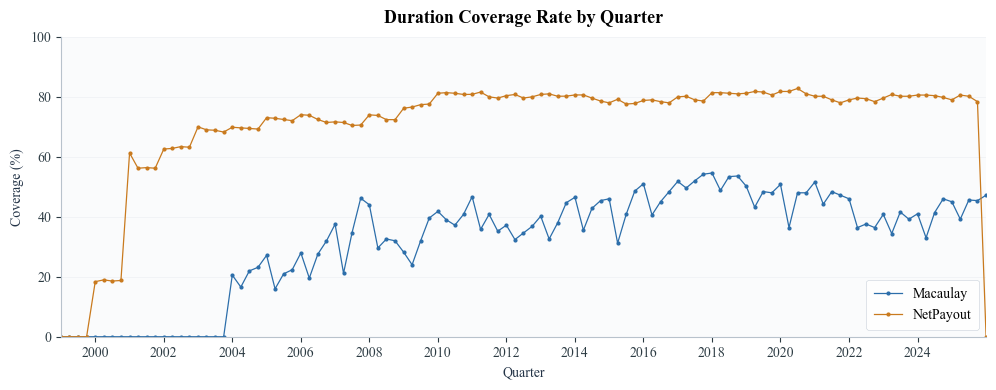

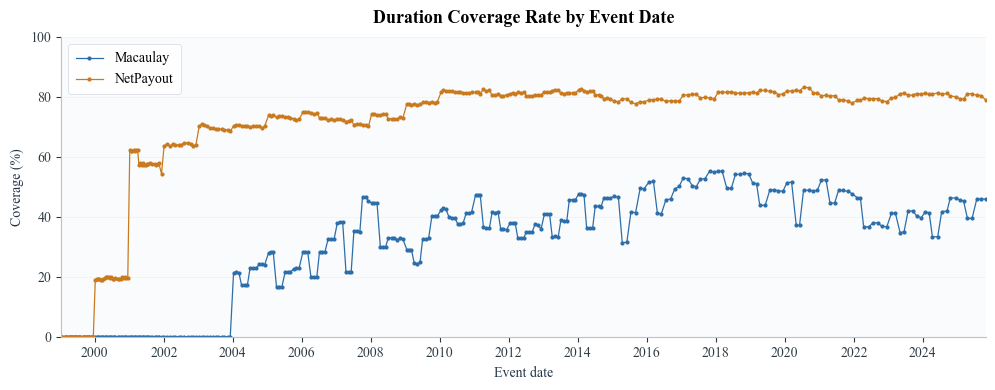

In [3]:
# Coverage diagnostic (old-definition): duration-panel coverage by quarter
# This avoids carry-forward from event as-of merges and reflects raw availability differences.

def _prep_duration_for_coverage(df_in, duration_candidates):
    d = df_in.copy()

    if 'status' in d.columns:
        d = d[d['status'].eq('ok')].copy()

    dur_col = first_existing(d, duration_candidates, required=True, label='duration column for coverage')
    date_col = first_existing(
        d,
        ['effective_date', 'asof_effective_date', 'asof_date', 'date', 'formation_date'],
        required=True,
        label='as-of date for coverage',
    )

    d['duration_value'] = pd.to_numeric(d[dur_col], errors='coerce')
    d['asof_effective_date'] = pd.to_datetime(d[date_col], errors='coerce').dt.normalize()

    key_cols = [c for c in ['RIC', 'firm_id'] if c in d.columns]
    if not key_cols:
        raise ValueError('Coverage prep requires RIC or firm_id in duration input.')

    d = d[key_cols + ['asof_effective_date', 'duration_value']].dropna(subset=['asof_effective_date']).copy()

    # Collapse duplicates at (id, as-of date) level like old workflow
    grp_keys = key_cols + ['asof_effective_date']
    d = d.groupby(grp_keys, as_index=False)['duration_value'].median()
    return d

mac_cov_panel = _prep_duration_for_coverage(
    df_mac,
    ['duration_macaulay_r125_clean', 'duration_macaulay_r125', 'duration_macaulay_r10_clean', 'duration_macaulay_r10'],
).rename(columns={'duration_value': 'Duration_Macaulay'})

np_cov_panel = _prep_duration_for_coverage(
    df_np,
    ['Duration_NetPayout_trim', 'Duration_NetPayout', 'Duration_NP_trim', 'Duration_NP', 'NP_Duration'],
).rename(columns={'duration_value': 'Duration_NetPayout'})

# Combine and collapse duplicates on shared keys
cov_frames = [mac_cov_panel, np_cov_panel]
df_cov = pd.concat(cov_frames, ignore_index=True, sort=False)
key_cols = [c for c in ['RIC', 'firm_id', 'asof_effective_date'] if c in df_cov.columns]

num_cols = [c for c in ['Duration_Macaulay', 'Duration_NetPayout'] if c in df_cov.columns]
df_cov = df_cov.groupby(key_cols, as_index=False)[num_cols].median()

# Overall table (old-style)
n_panel = len(df_cov)
cov_overall = pd.DataFrame(
    {
        'Duration': ['Duration_Macaulay', 'Duration_NetPayout'],
        'Coverage %': [
            100 * df_cov['Duration_Macaulay'].notna().mean() if 'Duration_Macaulay' in df_cov.columns and n_panel > 0 else np.nan,
            100 * df_cov['Duration_NetPayout'].notna().mean() if 'Duration_NetPayout' in df_cov.columns and n_panel > 0 else np.nan,
        ],
        'Covered Obs': [
            int(df_cov['Duration_Macaulay'].notna().sum()) if 'Duration_Macaulay' in df_cov.columns else np.nan,
            int(df_cov['Duration_NetPayout'].notna().sum()) if 'Duration_NetPayout' in df_cov.columns else np.nan,
        ],
        'Total Obs': [n_panel, n_panel],
    }
)
display(cov_overall)

# Coverage by quarter
cov_q = df_cov.copy()
cov_q['quarter'] = pd.to_datetime(cov_q['asof_effective_date'], errors='coerce').dt.to_period('Q').dt.to_timestamp()
cov_q = cov_q.dropna(subset=['quarter'])

cov_plot = (
    cov_q.groupby('quarter', as_index=True)[['Duration_Macaulay', 'Duration_NetPayout']]
    .apply(lambda g: g.notna().mean())
    .sort_index()
)

if cov_plot.empty:
    print('Coverage plot skipped: no quarterly coverage observations available.')
else:
    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(
        cov_plot.index,
        cov_plot['Duration_Macaulay'] * 100,
        marker='o',
        markersize=2.0,
        linewidth=0.9,
        label='Macaulay',
        color=COLORS['blue'],
    )
    ax.plot(
        cov_plot.index,
        cov_plot['Duration_NetPayout'] * 100,
        marker='o',
        markersize=2.0,
        linewidth=0.9,
        label='NetPayout',
        color=COLORS['orange'],
    )

    ax.set_title('Duration Coverage Rate by Quarter')
    ax.set_xlabel('Quarter')
    ax.set_ylabel('Coverage (%)')
    ax.set_ylim(0, 100)

    style_axes(ax, grid_axis='y', grid_alpha=0.25)
    x_min = pd.Timestamp('1999-01-01')
    x_max = min(pd.Timestamp('2025-12-31'), pd.to_datetime(cov_plot.index.max()))
    style_time_axis(
        ax,
        x_min=x_min,
        x_max=x_max,
        x_ticks=cov_plot.index,
        date_fmt='%Y',
    )
    style_legend(ax, loc='lower right')

    plt.tight_layout()
    plt.show()


# Coverage by event date (strict quarter match on event panel)
cov_evt = df_evt[['event_date', 'date', 'RIC', 'firm_id']].copy()

cov_evt, _ = merge_strict_quarter_feature(
    cov_evt,
    mac_cov_panel,
    'Duration_Macaulay',
    event_date_col='event_date',
    feature_date_col='asof_effective_date',
    key_priority=('RIC', 'firm_id'),
)
cov_evt, _ = merge_strict_quarter_feature(
    cov_evt,
    np_cov_panel,
    'Duration_NetPayout',
    event_date_col='event_date',
    feature_date_col='asof_effective_date',
    key_priority=('RIC', 'firm_id'),
)

cov_by_event = (
    cov_evt.groupby('event_date', as_index=False)[['Duration_Macaulay', 'Duration_NetPayout']]
    .agg(lambda s: s.notna().mean())
    .sort_values('event_date')
    .dropna(subset=['event_date'])
)

if cov_by_event.empty:
    print('Event coverage plot skipped: no event-level coverage observations available.')
else:
    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(
        cov_by_event['event_date'],
        cov_by_event['Duration_Macaulay'] * 100,
        marker='o',
        markersize=2.0,
        linewidth=0.9,
        label='Macaulay',
        color=COLORS['blue'],
    )
    ax.plot(
        cov_by_event['event_date'],
        cov_by_event['Duration_NetPayout'] * 100,
        marker='o',
        markersize=2.0,
        linewidth=0.9,
        label='NetPayout',
        color=COLORS['orange'],
    )

    ax.set_title('Duration Coverage Rate by Event Date')
    ax.set_xlabel('Event date')
    ax.set_ylabel('Coverage (%)')
    ax.set_ylim(0, 100)

    style_axes(ax, grid_axis='y', grid_alpha=0.25)
    style_time_axis(
        ax,
        x_min=cov_by_event['event_date'].min(),
        x_max=cov_by_event['event_date'].max(),
        x_ticks=cov_by_event['event_date'],
        date_fmt='%Y',
    )
    style_legend(ax, loc='best')

    plt.tight_layout()
    plt.show()


## 3. Define key variables

In [4]:
# Duration source selection
mac_dur_col = first_existing(
    df_mac,
    ['duration_macaulay_r125_clean', 'duration_macaulay_r125', 'duration_macaulay_r10_clean', 'duration_macaulay_r10'],
    required=True,
    label='Macaulay duration'
)
np_dur_col = first_existing(
    df_np,
    ['Duration_NetPayout_trim', 'Duration_NetPayout', 'Duration_NP_trim', 'Duration_NP', 'NP_Duration'],
    required=True,
    label='NetPayout duration'
)

# Build compact quarter-matched feature panel from Macaulay source (duration) + NP source (duration + controls)
mac_feat = df_mac.copy()
mac_feat['Duration_Macaulay'] = pd.to_numeric(mac_feat[mac_dur_col], errors='coerce')
mac_feat_date_col = first_existing(mac_feat, ['effective_date', 'asof_effective_date', 'date', 'formation_date'], required=True, label='Macaulay date')
mac_feat = mac_feat.rename(columns={mac_feat_date_col: 'asof_effective_date'})
mac_feat = mac_feat[[c for c in ['RIC', 'firm_id', 'asof_effective_date', 'Duration_Macaulay'] if c in mac_feat.columns]].copy()

np_feat = df_np.copy()
np_feat['Duration_NetPayout'] = pd.to_numeric(np_feat[np_dur_col], errors='coerce')
np_feat_date_col = first_existing(np_feat, ['effective_date', 'asof_effective_date', 'date', 'formation_date'], required=True, label='NetPayout date')
np_feat = np_feat.rename(columns={np_feat_date_col: 'asof_effective_date'})

if 'beta' in np_feat.columns:
    np_feat['beta'] = pd.to_numeric(np_feat['beta'], errors='coerce')
mcap_col = first_existing(np_feat, ['mcap_eur', 'MCAP_Q', 'MCAP_Y'])
if mcap_col is not None:
    np_feat['log_mcap'] = np.log(pd.to_numeric(np_feat[mcap_col], errors='coerce').clip(lower=1e-12))
lev_col = first_existing(np_feat, ['lev', 'blev', 'leverage'])
if lev_col is not None:
    np_feat['leverage'] = pd.to_numeric(np_feat[lev_col], errors='coerce')
bm_col = first_existing(np_feat, ['bm', 'book_to_market', 'BE'])
if bm_col is not None and bm_col != 'BE':
    np_feat['bm'] = pd.to_numeric(np_feat[bm_col], errors='coerce')

np_keep = [c for c in ['RIC', 'firm_id', 'asof_effective_date', 'Duration_NetPayout', 'beta', 'log_mcap', 'leverage', 'bm', 'trbc_sector'] if c in np_feat.columns]
np_feat = np_feat[np_keep].copy()

# Merge all key variables using strict quarter match (event quarter == feature quarter)
for col in ['Duration_Macaulay']:
    df_evt, _ = merge_strict_quarter_feature(df_evt, mac_feat, value_col=col, event_date_col='event_date', feature_date_col='asof_effective_date', key_priority=('RIC', 'firm_id'))

for col in ['Duration_NetPayout', 'beta', 'log_mcap', 'leverage', 'bm', 'trbc_sector']:
    if col in np_feat.columns:
        df_evt, _ = merge_strict_quarter_feature(df_evt, np_feat, value_col=col, event_date_col='event_date', feature_date_col='asof_effective_date', key_priority=('RIC', 'firm_id'))

# Optional financials exclusion if sector available
if 'trbc_sector' in df_evt.columns:
    sec = df_evt['trbc_sector'].astype('string').str.strip().str.casefold()
    df_evt = df_evt[sec.ne('financials') | sec.isna()].copy()

available_depvars = [c for c in ['AR_0', 'AR_0_1', 'AR_m1_1'] if c in df_evt.columns]
print('Available dependent variables:', available_depvars)
print('Final event panel shape:', df_evt.shape)


Available dependent variables: ['AR_0', 'AR_0_1', 'AR_m1_1']
Final event panel shape: (129513, 29)


## 4. Standardize variables

In [5]:
def zscore_by_year(df, col, year_col='year_pred'):
    def _z(s):
        s = pd.to_numeric(s, errors='coerce')
        mu = s.mean(skipna=True)
        sd = s.std(skipna=True, ddof=0)
        if pd.isna(sd) or sd == 0:
            return pd.Series(np.nan, index=s.index)
        return (s - mu) / sd
    return df.groupby(year_col, dropna=False)[col].transform(_z)

std_map = {
    'Duration_Macaulay': 'Duration_Macaulay_std',
    'Duration_NetPayout': 'Duration_NetPayout_std',
    'beta': 'beta_std',
    'log_mcap': 'log_mcap_std',
    'leverage': 'leverage_std',
    'bm': 'bm_std',
}

for raw_col, std_col in std_map.items():
    if raw_col in df_evt.columns:
        df_evt[std_col] = zscore_by_year(df_evt, raw_col, year_col='year_pred')

std_cols_present = [c for c in std_map.values() if c in df_evt.columns]
display(df_evt[std_cols_present].describe().T[['mean', 'std', 'count']])

,mean,std,count
Duration_Macaulay_std,0.0,1.000014,36846.0
Duration_NetPayout_std,0.0,1.000005,97551.0
log_mcap_std,-0.0,1.000004,129400.0
leverage_std,-0.0,1.000004,119973.0
bm_std,0.0,1.000004,120631.0


## 5. Define regression helper functions

In [6]:
def build_formula(depvar, duration_var, include_event_fe=False, include_raw_shocks=False, controls=None):
    controls = controls or []
    terms = [
        f'ShockMP:{duration_var}',
        f'ShockInfo:{duration_var}',
    ]
    if 'beta' in controls:
        terms += ['ShockMP:beta_std', 'ShockInfo:beta_std']
    if 'size' in controls:
        terms += ['ShockMP:log_mcap_std', 'ShockInfo:log_mcap_std']
    if 'leverage' in controls:
        terms += ['ShockMP:leverage_std', 'ShockInfo:leverage_std']
    if 'bm' in controls:
        terms += ['ShockMP:bm_std', 'ShockInfo:bm_std']
    if include_raw_shocks:
        terms += ['ShockMP', 'ShockInfo']
    if include_event_fe:
        terms += ['C(event_date)']
    rhs = ' + '.join(terms)
    return f'{depvar} ~ 0 + {rhs}', terms

def _safe_get(series, key):
    return float(series[key]) if key in series.index else np.nan

def _cluster_groups(df, cluster='event'):
    if cluster == 'twoway' and 'firm_id' in df.columns:
        return np.column_stack([pd.Categorical(df['event_date']).codes, pd.Categorical(df['firm_id']).codes])
    return pd.Categorical(df['event_date']).codes

def _clean_controls_label(controls):
    if not controls:
        return 'None'
    label_map = {'beta': 'beta', 'size': 'size', 'leverage': 'leverage', 'bm': 'bm'}
    return ', '.join(label_map[c] for c in controls if c in label_map)

def _sig_stars(p):
    if pd.isna(p):
        return ''
    if p < 0.01:
        return '***'
    if p < 0.05:
        return '**'
    if p < 0.10:
        return '*'
    return ''

def _coef_term(shock_name, duration_var):
    return f'{shock_name}:{duration_var}'

def run_regression(df, depvar, duration_var, specification_name, include_event_fe=False, include_raw_shocks=False, controls=None, cluster='event'):
    controls = controls or []
    formula, terms = build_formula(
        depvar=depvar,
        duration_var=duration_var,
        include_event_fe=include_event_fe,
        include_raw_shocks=include_raw_shocks,
        controls=controls,
    )

    needed = [depvar, 'ShockMP', 'ShockInfo', duration_var, 'event_date', 'firm_id']
    if 'beta' in controls:
        needed.append('beta_std')
    if 'size' in controls:
        needed.append('log_mcap_std')
    if 'leverage' in controls:
        needed.append('leverage_std')
    if 'bm' in controls:
        needed.append('bm_std')

    work = df[[c for c in needed if c in df.columns]].dropna().copy()
    if work.empty:
        return None

    model = smf.ols(formula=formula, data=work)
    groups = _cluster_groups(work, cluster=cluster)
    res = model.fit(cov_type='cluster', cov_kwds={'groups': groups})

    mp_term = _coef_term('ShockMP', duration_var)
    info_term = _coef_term('ShockInfo', duration_var)
    beta_mp = 'ShockMP:beta_std'
    beta_info = 'ShockInfo:beta_std'
    size_mp = 'ShockMP:log_mcap_std'
    size_info = 'ShockInfo:log_mcap_std'
    lev_mp = 'ShockMP:leverage_std'
    lev_info = 'ShockInfo:leverage_std'

    row = {
        'depvar': depvar,
        'duration_name': duration_var,
        'specification_name': specification_name,
        'event_FE': 'Yes' if include_event_fe else 'No',
        'controls': _clean_controls_label(controls),
        'coef_mp_duration': _safe_get(res.params, mp_term),
        'se_mp_duration': _safe_get(res.bse, mp_term),
        't_mp_duration': _safe_get(res.tvalues, mp_term),
        'p_mp_duration': _safe_get(res.pvalues, mp_term),
        'coef_info_duration': _safe_get(res.params, info_term),
        'se_info_duration': _safe_get(res.bse, info_term),
        't_info_duration': _safe_get(res.tvalues, info_term),
        'p_info_duration': _safe_get(res.pvalues, info_term),
        'coef_mp_beta': _safe_get(res.params, beta_mp),
        'coef_info_beta': _safe_get(res.params, beta_info),
        'coef_mp_size': _safe_get(res.params, size_mp),
        'coef_info_size': _safe_get(res.params, size_info),
        'coef_mp_leverage': _safe_get(res.params, lev_mp),
        'coef_info_leverage': _safe_get(res.params, lev_info),
        'N': int(res.nobs),
        'n_events': int(work['event_date'].nunique()),
        'r_squared': float(res.rsquared) if hasattr(res, 'rsquared') else np.nan,
        'model_obj': res,
    }
    return row

def make_reader_entry(coef, t_stat, p):
    if pd.isna(coef):
        return ''
    return f'{coef:.4f}{_sig_stars(p)} ({t_stat:.2f})'

## 6. Estimate main models

In [7]:
depvars_main = [c for c in ['AR_0', 'AR_0_1'] if c in df_evt.columns]
duration_vars = [c for c in ['Duration_Macaulay_std', 'Duration_NetPayout_std'] if c in df_evt.columns]

controls_available = {
    'beta': 'beta_std' in df_evt.columns,
    'size': 'log_mcap_std' in df_evt.columns,
    'leverage': 'leverage_std' in df_evt.columns,
    'bm': 'bm_std' in df_evt.columns,
}

ctrl_beta = [c for c in ['beta'] if controls_available.get(c)]
ctrl_plus = [c for c in ['beta', 'size', 'leverage'] if controls_available.get(c)]

spec_grid = [
    {'name': 'Model 1: Basic two-shock interaction', 'event_fe': False, 'raw_shocks': False, 'controls': []},
    {'name': 'Model 2: + beta interactions', 'event_fe': False, 'raw_shocks': False, 'controls': ctrl_beta},
    {'name': 'Model 3: + size/leverage interactions (if available)', 'event_fe': False, 'raw_shocks': False, 'controls': ctrl_plus},
    {'name': 'Model 4: Event FE', 'event_fe': True, 'raw_shocks': False, 'controls': ctrl_plus},
    {'name': 'Model 5: No Event FE (+ raw shocks)', 'event_fe': False, 'raw_shocks': True, 'controls': ctrl_plus},
]

results = []
for dep in depvars_main:
    for dur in duration_vars:
        for spec in spec_grid:
            row = run_regression(
                df=df_evt,
                depvar=dep,
                duration_var=dur,
                specification_name=spec['name'],
                include_event_fe=spec['event_fe'],
                include_raw_shocks=spec['raw_shocks'],
                controls=spec['controls'],
                cluster='event',
            )
            if row is not None:
                results.append(row)

df_results = pd.DataFrame(results)
if df_results.empty:
    raise ValueError('No models estimated. Check data availability and variable merges.')

display(df_results[['depvar', 'duration_name', 'specification_name', 'event_FE', 'controls', 'N', 'n_events', 'r_squared']])

,depvar,duration_name,specification_name,event_FE,controls,N,n_events,r_squared
0,AR_0,Duration_Macaulay_std,Model 1: Basic two-shock interaction,No,None,36846,219,0.000684
1,AR_0,Duration_Macaulay_std,Model 2: + beta interactions,No,None,36846,219,0.000684
2,AR_0,Duration_Macaulay_std,Model 3: + size/leverage interactions (if avai...,No,"size, leverage",36089,219,0.001318
3,AR_0,Duration_Macaulay_std,Model 4: Event FE,Yes,"size, leverage",36089,219,0.051134
4,AR_0,Duration_Macaulay_std,Model 5: No Event FE (+ raw shocks),No,"size, leverage",36089,219,0.005314
5,AR_0,Duration_NetPayout_std,Model 1: Basic two-shock interaction,No,None,97551,289,0.000365
6,AR_0,Duration_NetPayout_std,Model 2: + beta interactions,No,None,97551,289,0.000365
7,AR_0,Duration_NetPayout_std,Model 3: + size/leverage interactions (if avai...,No,"size, leverage",97551,289,0.001683
8,AR_0,Duration_NetPayout_std,Model 4: Event FE,Yes,"size, leverage",97551,289,0.078447
9,AR_0,Duration_NetPayout_std,Model 5: No Event FE (+ raw shocks),No,"size, leverage",97551,289,0.006531


## 7. Estimate robustness models

In [8]:
robust_rows = []

# Optional placebo depvar
if 'AR_m1_1' in df_evt.columns:
    for dur in duration_vars:
        row = run_regression(
            df=df_evt,
            depvar='AR_m1_1',
            duration_var=dur,
            specification_name='Robustness: Placebo AR_m1_1 (Event FE)',
            include_event_fe=True,
            include_raw_shocks=False,
            controls=ctrl_plus,
            cluster='event',
        )
        if row is not None:
            robust_rows.append(row)

# Optional two-way clustering robustness
for dep in depvars_main:
    for dur in duration_vars:
        row = run_regression(
            df=df_evt,
            depvar=dep,
            duration_var=dur,
            specification_name='Robustness: Model 4 with two-way clustering',
            include_event_fe=True,
            include_raw_shocks=False,
            controls=ctrl_plus,
            cluster='twoway',
        )
        if row is not None:
            robust_rows.append(row)

df_robust = pd.DataFrame(robust_rows)
if not df_robust.empty:
    display(df_robust[['depvar', 'duration_name', 'specification_name', 'event_FE', 'controls', 'N', 'n_events']])
else:
    print('No additional robustness models estimated.')

/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Code/.venv Masterarbeit/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Code/.venv Masterarbeit/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Code/.venv Masterarbeit/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Code/.venv Masterarbeit/lib/python3.13/site-packages/statsmodels/regression/linear_model.

,depvar,duration_name,specification_name,event_FE,controls,N,n_events
0,AR_m1_1,Duration_Macaulay_std,Robustness: Placebo AR_m1_1 (Event FE),Yes,"size, leverage",35948,219
1,AR_m1_1,Duration_NetPayout_std,Robustness: Placebo AR_m1_1 (Event FE),Yes,"size, leverage",97170,289
2,AR_0,Duration_Macaulay_std,Robustness: Model 4 with two-way clustering,Yes,"size, leverage",36089,219
3,AR_0,Duration_NetPayout_std,Robustness: Model 4 with two-way clustering,Yes,"size, leverage",97551,289
4,AR_0_1,Duration_Macaulay_std,Robustness: Model 4 with two-way clustering,Yes,"size, leverage",35950,219
5,AR_0_1,Duration_NetPayout_std,Robustness: Model 4 with two-way clustering,Yes,"size, leverage",97184,289


## 8. Build tidy results tables

In [9]:
def _duration_label(x):
    return x.replace('_std', '').replace('Duration_', '')

tbl = df_results.copy()
tbl['Duration'] = tbl['duration_name'].map(_duration_label)
tbl['Specification'] = tbl['specification_name']
tbl['Event FE'] = tbl['event_FE']
tbl['Controls'] = tbl['controls']

fmt_cols = ['coef_mp_duration', 't_mp_duration', 'p_mp_duration', 'coef_info_duration', 't_info_duration', 'p_info_duration']
for c in fmt_cols:
    tbl[c] = pd.to_numeric(tbl[c], errors='coerce')

table_cols = [
    'Duration', 'Specification', 'Event FE', 'Controls',
    'coef_mp_duration', 't_mp_duration', 'p_mp_duration',
    'coef_info_duration', 't_info_duration', 'p_info_duration',
    'N', 'n_events'
]

TABLE_A = (
    tbl[tbl['depvar'] == 'AR_0_1'][table_cols]
    .rename(columns={
        'coef_mp_duration': 'ShockMP × Duration',
        't_mp_duration': 't-stat MP',
        'p_mp_duration': 'p-value MP',
        'coef_info_duration': 'ShockInfo × Duration',
        't_info_duration': 't-stat Info',
        'p_info_duration': 'p-value Info',
        'n_events': 'Events',
    })
)

TABLE_B = (
    tbl[tbl['depvar'] == 'AR_0'][table_cols]
    .rename(columns={
        'coef_mp_duration': 'ShockMP × Duration',
        't_mp_duration': 't-stat MP',
        'p_mp_duration': 'p-value MP',
        'coef_info_duration': 'ShockInfo × Duration',
        't_info_duration': 't-stat Info',
        'p_info_duration': 'p-value Info',
        'n_events': 'Events',
    })
)

for _t in [TABLE_A, TABLE_B]:
    for c in ['ShockMP × Duration', 't-stat MP', 'p-value MP', 'ShockInfo × Duration', 't-stat Info', 'p-value Info']:
        _t[c] = _t[c].map(lambda v: f'{v:.4f}' if pd.notna(v) else '')

reader = tbl.copy()
reader['ShockMP × Duration'] = reader.apply(lambda r: make_reader_entry(r['coef_mp_duration'], r['t_mp_duration'], r['p_mp_duration']), axis=1)
reader['ShockInfo × Duration'] = reader.apply(lambda r: make_reader_entry(r['coef_info_duration'], r['t_info_duration'], r['p_info_duration']), axis=1)
TABLE_READER = reader[['depvar', 'Duration', 'Specification', 'Event FE', 'Controls', 'ShockMP × Duration', 'ShockInfo × Duration', 'N', 'n_events']].rename(columns={'depvar': 'Return window', 'n_events': 'Events'})

print('TABLE A: Main results for AR_0_1')
display(TABLE_A)
print('TABLE B: Main results for AR_0')
display(TABLE_B)
print('Reader table (coef*** (t-stat))')
display(TABLE_READER)

TABLE A: Main results for AR_0_1


,Duration,Specification,Event FE,Controls,ShockMP × Duration,t-stat MP,p-value MP,ShockInfo × Duration,t-stat Info,p-value Info,N,Events
10,Macaulay,Model 1: Basic two-shock interaction,No,None,0.0265,2.2287,0.0258,0.0021,0.2211,0.8250,36705,219
11,Macaulay,Model 2: + beta interactions,No,None,0.0265,2.2287,0.0258,0.0021,0.2211,0.8250,36705,219
12,Macaulay,Model 3: + size/leverage interactions (if avai...,No,"size, leverage",0.0228,2.0100,0.0444,-0.0012,-0.1448,0.8849,35950,219
13,Macaulay,Model 4: Event FE,Yes,"size, leverage",0.0214,1.6350,0.1020,-0.0033,-0.2873,0.7739,35950,219
14,Macaulay,Model 5: No Event FE (+ raw shocks),No,"size, leverage",0.0255,2.0970,0.0360,-0.0060,-0.5830,0.5599,35950,219
15,NetPayout,Model 1: Basic two-shock interaction,No,None,-0.0039,-0.8159,0.4145,0.0050,0.6724,0.5013,97184,289
16,NetPayout,Model 2: + beta interactions,No,None,-0.0039,-0.8159,0.4145,0.0050,0.6724,0.5013,97184,289
17,NetPayout,Model 3: + size/leverage interactions (if avai...,No,"size, leverage",-0.0022,-0.4118,0.6805,0.0082,1.0985,0.2720,97184,289
18,NetPayout,Model 4: Event FE,Yes,"size, leverage",-0.0020,-0.3861,0.6994,0.0079,1.0587,0.2897,97184,289
19,NetPayout,Model 5: No Event FE (+ raw shocks),No,"size, leverage",-0.0019,-0.3701,0.7113,0.0080,1.0574,0.2903,97184,289


TABLE B: Main results for AR_0


,Duration,Specification,Event FE,Controls,ShockMP × Duration,t-stat MP,p-value MP,ShockInfo × Duration,t-stat Info,p-value Info,N,Events
0,Macaulay,Model 1: Basic two-shock interaction,No,None,0.0145,1.4991,0.1338,0.0015,0.2345,0.8146,36846,219
1,Macaulay,Model 2: + beta interactions,No,None,0.0145,1.4991,0.1338,0.0015,0.2345,0.8146,36846,219
2,Macaulay,Model 3: + size/leverage interactions (if avai...,No,"size, leverage",0.0111,1.3625,0.1730,-0.0002,-0.0372,0.9703,36089,219
3,Macaulay,Model 4: Event FE,Yes,"size, leverage",0.0160,1.4237,0.1545,-0.0077,-1.4217,0.1551,36089,219
4,Macaulay,Model 5: No Event FE (+ raw shocks),No,"size, leverage",0.0176,1.7196,0.0855,-0.0060,-1.2462,0.2127,36089,219
5,NetPayout,Model 1: Basic two-shock interaction,No,None,-0.0095,-2.9612,0.0031,0.0092,2.2040,0.0275,97551,289
6,NetPayout,Model 2: + beta interactions,No,None,-0.0095,-2.9612,0.0031,0.0092,2.2040,0.0275,97551,289
7,NetPayout,Model 3: + size/leverage interactions (if avai...,No,"size, leverage",-0.0081,-2.2762,0.0228,0.0126,2.8722,0.0041,97551,289
8,NetPayout,Model 4: Event FE,Yes,"size, leverage",-0.0077,-2.1225,0.0338,0.0122,2.7980,0.0051,97551,289
9,NetPayout,Model 5: No Event FE (+ raw shocks),No,"size, leverage",-0.0078,-2.1715,0.0299,0.0123,2.8002,0.0051,97551,289


Reader table (coef*** (t-stat))


,Return window,Duration,Specification,Event FE,Controls,ShockMP × Duration,ShockInfo × Duration,N,Events
0,AR_0,Macaulay,Model 1: Basic two-shock interaction,No,None,0.0145 (1.50),0.0015 (0.23),36846,219
1,AR_0,Macaulay,Model 2: + beta interactions,No,None,0.0145 (1.50),0.0015 (0.23),36846,219
2,AR_0,Macaulay,Model 3: + size/leverage interactions (if avai...,No,"size, leverage",0.0111 (1.36),-0.0002 (-0.04),36089,219
3,AR_0,Macaulay,Model 4: Event FE,Yes,"size, leverage",0.0160 (1.42),-0.0077 (-1.42),36089,219
4,AR_0,Macaulay,Model 5: No Event FE (+ raw shocks),No,"size, leverage",0.0176* (1.72),-0.0060 (-1.25),36089,219
5,AR_0,NetPayout,Model 1: Basic two-shock interaction,No,None,-0.0095*** (-2.96),0.0092** (2.20),97551,289
6,AR_0,NetPayout,Model 2: + beta interactions,No,None,-0.0095*** (-2.96),0.0092** (2.20),97551,289
7,AR_0,NetPayout,Model 3: + size/leverage interactions (if avai...,No,"size, leverage",-0.0081** (-2.28),0.0126*** (2.87),97551,289
8,AR_0,NetPayout,Model 4: Event FE,Yes,"size, leverage",-0.0077** (-2.12),0.0122*** (2.80),97551,289
9,AR_0,NetPayout,Model 5: No Event FE (+ raw shocks),No,"size, leverage",-0.0078** (-2.17),0.0123*** (2.80),97551,289


## 8b. Side-by-side comparison tables

In [10]:
compact = tbl[['depvar', 'duration_name', 'specification_name', 'event_FE', 'coef_mp_duration', 'coef_info_duration', 't_mp_duration', 't_info_duration']].copy()
compact['mp_reader'] = compact.apply(lambda r: make_reader_entry(r['coef_mp_duration'], r['t_mp_duration'], np.nan), axis=1)
compact['info_reader'] = compact.apply(lambda r: make_reader_entry(r['coef_info_duration'], r['t_info_duration'], np.nan), axis=1)

# Comparison 1: Macaulay vs NetPayout (same return window, same specification)
CMP_1 = (
    compact[compact['depvar'] == 'AR_0_1']
    .pivot_table(index=['depvar', 'specification_name', 'event_FE'], columns='duration_name', values=['mp_reader', 'info_reader'], aggfunc='first')
    .sort_index()
)

# Comparison 2: AR_0 vs AR_0_1 (same duration, same specification)
CMP_2 = (
    compact[compact['depvar'].isin(['AR_0', 'AR_0_1'])]
    .pivot_table(index=['duration_name', 'specification_name', 'event_FE'], columns='depvar', values=['mp_reader', 'info_reader'], aggfunc='first')
    .sort_index()
)

# Comparison 3: Event FE vs No Event FE (same duration, same return window; focus on Model 4 vs Model 5)
cmp3_base = compact[compact['specification_name'].isin(['Model 4: Event FE', 'Model 5: No Event FE (+ raw shocks)'])].copy()
CMP_3 = (
    cmp3_base
    .pivot_table(index=['depvar', 'duration_name'], columns='specification_name', values=['mp_reader', 'info_reader'], aggfunc='first')
    .sort_index()
)

print('Comparison Table 1: Macaulay vs NetPayout')
display(CMP_1)
print('Comparison Table 2: AR_0 vs AR_0_1')
display(CMP_2)
print('Comparison Table 3: Event FE vs No Event FE')
display(CMP_3)

Comparison Table 1: Macaulay vs NetPayout


info_reader                                    mp_reader                       
duration_name                                                      Duration_Macaulay_std Duration_NetPayout_std Duration_Macaulay_std Duration_NetPayout_std
depvar specification_name                                 event_FE                                                                                          
AR_0_1 Model 1: Basic two-shock interaction               No               0.0021 (0.22)          0.0050 (0.67)         0.0265 (2.23)        -0.0039 (-0.82)
       Model 2: + beta interactions                       No               0.0021 (0.22)          0.0050 (0.67)         0.0265 (2.23)        -0.0039 (-0.82)
       Model 3: + size/leverage interactions (if avail... No             -0.0012 (-0.14)          0.0082 (1.10)         0.0228 (2.01)        -0.0022 (-0.41)
       Model 4: Event FE                                  Yes            -0.0033 (-0.29)          0.0079 (1.06)         0.0214 (1.64)        -0.0020 (-0.39)
       Model 5: No Event FE (+ raw shocks)                No             -0.0060 (-0.58)          0.0080 (1.06)         0.0255 (2.10)        -0.0019 (-0.37)

Comparison Table 2: AR_0 vs AR_0_1


info_reader                         mp_reader                 
depvar                                                                                         AR_0           AR_0_1             AR_0           AR_0_1
duration_name          specification_name                                 event_FE                                                                    
Duration_Macaulay_std  Model 1: Basic two-shock interaction               No          0.0015 (0.23)    0.0021 (0.22)    0.0145 (1.50)    0.0265 (2.23)
                       Model 2: + beta interactions                       No          0.0015 (0.23)    0.0021 (0.22)    0.0145 (1.50)    0.0265 (2.23)
                       Model 3: + size/leverage interactions (if avail... No        -0.0002 (-0.04)  -0.0012 (-0.14)    0.0111 (1.36)    0.0228 (2.01)
                       Model 4: Event FE                                  Yes       -0.0077 (-1.42)  -0.0033 (-0.29)    0.0160 (1.42)    0.0214 (1.64)
                       Model 5: No Event FE (+ raw shocks)                No        -0.0060 (-1.25)  -0.0060 (-0.58)    0.0176 (1.72)    0.0255 (2.10)
Duration_NetPayout_std Model 1: Basic two-shock interaction               No          0.0092 (2.20)    0.0050 (0.67)  -0.0095 (-2.96)  -0.0039 (-0.82)
                       Model 2: + beta interactions                       No          0.0092 (2.20)    0.0050 (0.67)  -0.0095 (-2.96)  -0.0039 (-0.82)
                       Model 3: + size/leverage interactions (if avail... No          0.0126 (2.87)    0.0082 (1.10)  -0.0081 (-2.28)  -0.0022 (-0.41)
                       Model 4: Event FE                                  Yes         0.0122 (2.80)    0.0079 (1.06)  -0.0077 (-2.12)  -0.0020 (-0.39)
                       Model 5: No Event FE (+ raw shocks)                No          0.0123 (2.80)    0.0080 (1.06)  -0.0078 (-2.17)  -0.0019 (-0.37)

Comparison Table 3: Event FE vs No Event FE


info_reader                                             mp_reader                                    
specification_name            Model 4: Event FE Model 5: No Event FE (+ raw shocks) Model 4: Event FE Model 5: No Event FE (+ raw shocks)
depvar duration_name                                                                                                                     
AR_0   Duration_Macaulay_std    -0.0077 (-1.42)                     -0.0060 (-1.25)     0.0160 (1.42)                       0.0176 (1.72)
       Duration_NetPayout_std     0.0122 (2.80)                       0.0123 (2.80)   -0.0077 (-2.12)                     -0.0078 (-2.17)
AR_0_1 Duration_Macaulay_std    -0.0033 (-0.29)                     -0.0060 (-0.58)     0.0214 (1.64)                       0.0255 (2.10)
       Duration_NetPayout_std     0.0079 (1.06)                       0.0080 (1.06)   -0.0020 (-0.39)                     -0.0019 (-0.37)

## 9. Create coefficient plots

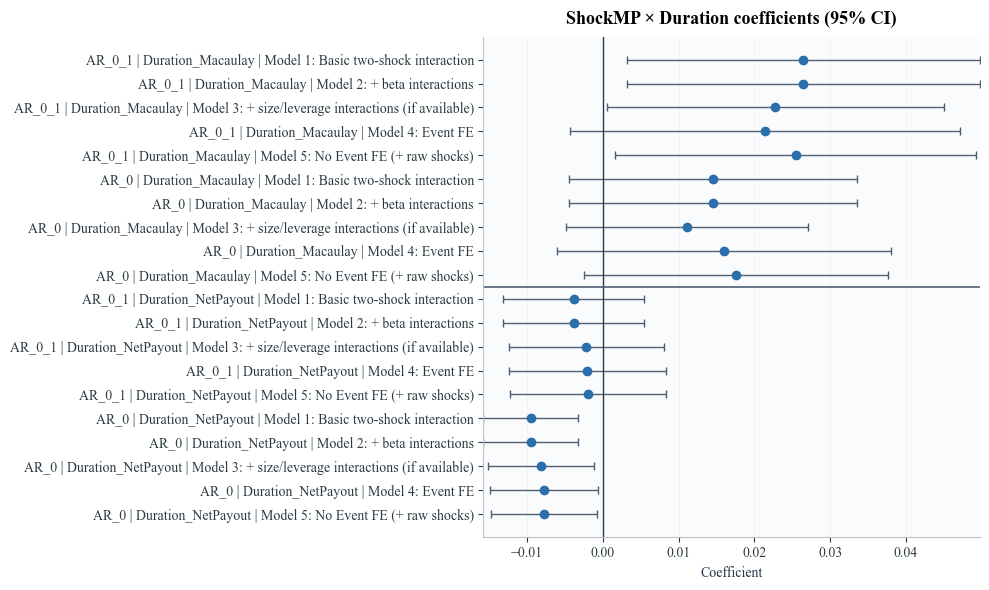

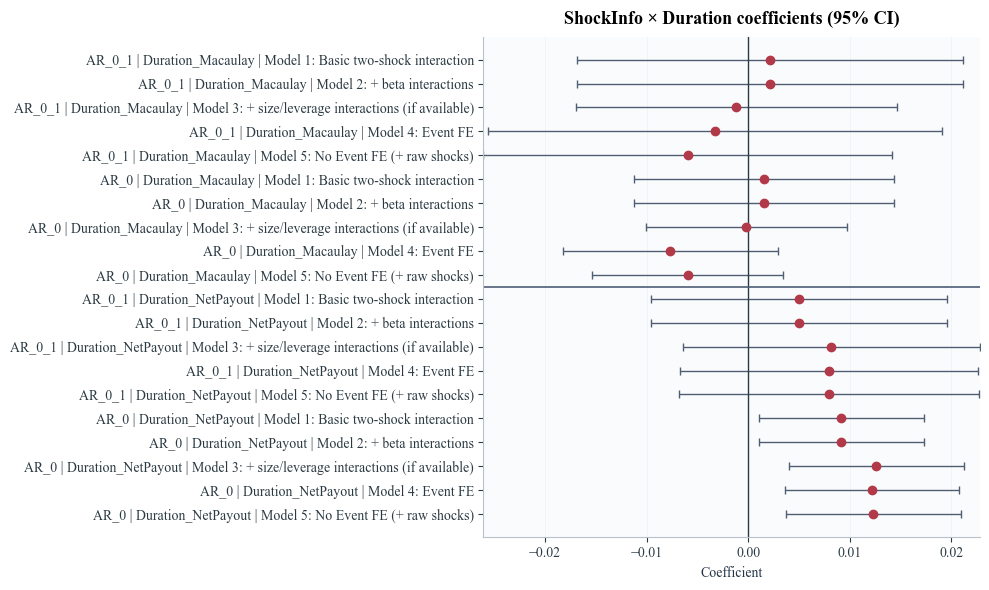

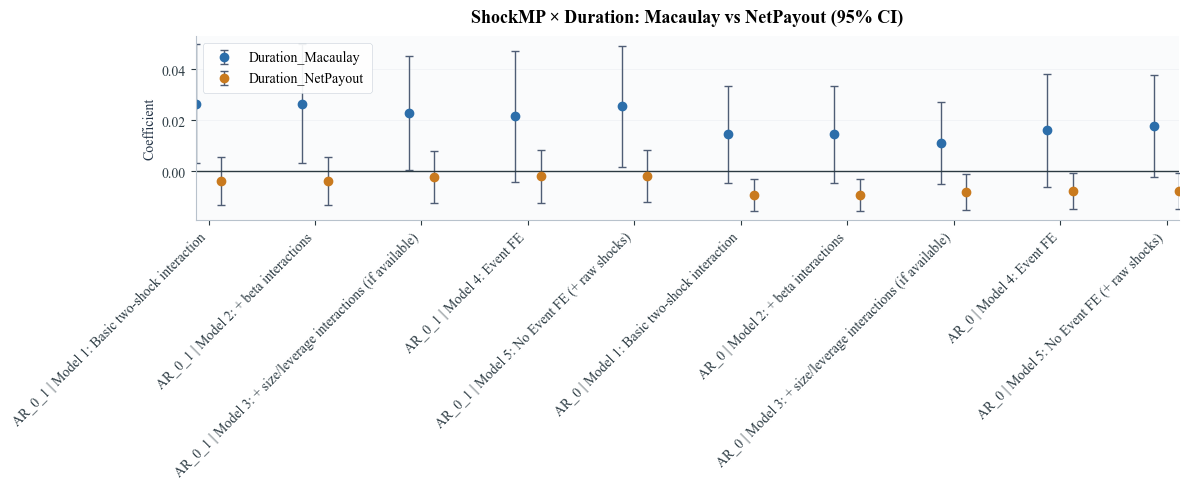

In [11]:
plot_df = df_results.copy()
plot_df['label'] = plot_df['depvar'] + ' | ' + plot_df['duration_name'].str.replace('_std', '', regex=False) + ' | ' + plot_df['specification_name']

duration_order_map = {
    'Duration_Macaulay_std': 0,
    'Duration_NetPayout_std': 1,
}
depvar_order_map = {
    'AR_0_1': 0,
    'AR_0': 1,
}
spec_order_map = {
    'Model 1: Basic two-shock interaction': 0,
    'Model 2: + beta interactions': 1,
    'Model 3: + size/leverage interactions (if available)': 2,
    'Model 4: Event FE': 3,
    'Model 5: No Event FE (+ raw shocks)': 4,
}

def coef_ci_ordered(df, coef_col, se_col):
    d = df[['label', 'duration_name', 'depvar', 'specification_name', coef_col, se_col]].dropna().copy()
    d['duration_order'] = d['duration_name'].map(duration_order_map).fillna(99)
    d['depvar_order'] = d['depvar'].map(depvar_order_map).fillna(99)
    d['spec_order'] = d['specification_name'].map(spec_order_map).fillna(99)
    d = d.sort_values(['duration_order', 'depvar_order', 'spec_order']).reset_index(drop=True)
    d['lo'] = d[coef_col] - 1.96 * d[se_col]
    d['hi'] = d[coef_col] + 1.96 * d[se_col]
    return d

# Plot 1: ShockMP x Duration
p1 = coef_ci_ordered(plot_df, 'coef_mp_duration', 'se_mp_duration')
fig, ax = plt.subplots(figsize=(10, max(4, 0.3 * len(p1))))
y = np.arange(len(p1))
ax.errorbar(
    p1['coef_mp_duration'],
    y,
    xerr=1.96 * p1['se_mp_duration'],
    fmt='o',
    color=COLORS['blue'],
    ecolor=COLORS['neutral'],
    capsize=3,
)
ax.axvline(0, color=COLORS['reference'], linewidth=1)

if p1['duration_name'].eq('Duration_Macaulay_std').any() and p1['duration_name'].eq('Duration_NetPayout_std').any():
    split_idx = int(p1['duration_name'].eq('Duration_Macaulay_std').sum())
    ax.axhline(split_idx - 0.5, color=COLORS['neutral'], linewidth=1.2)

ax.set_yticks(y)
ax.set_yticklabels(p1['label'])
ax.invert_yaxis()
ax.set_title('ShockMP × Duration coefficients (95% CI)')
ax.set_xlabel('Coefficient')
style_axes(ax, grid_axis='x', grid_alpha=0.25)
plt.tight_layout()
plt.show()

# Plot 2: ShockInfo x Duration
p2 = coef_ci_ordered(plot_df, 'coef_info_duration', 'se_info_duration')
fig, ax = plt.subplots(figsize=(10, max(4, 0.3 * len(p2))))
y = np.arange(len(p2))
ax.errorbar(
    p2['coef_info_duration'],
    y,
    xerr=1.96 * p2['se_info_duration'],
    fmt='o',
    color=COLORS['accent'],
    ecolor=COLORS['neutral'],
    capsize=3,
)
ax.axvline(0, color=COLORS['reference'], linewidth=1)

if p2['duration_name'].eq('Duration_Macaulay_std').any() and p2['duration_name'].eq('Duration_NetPayout_std').any():
    split_idx = int(p2['duration_name'].eq('Duration_Macaulay_std').sum())
    ax.axhline(split_idx - 0.5, color=COLORS['neutral'], linewidth=1.2)

ax.set_yticks(y)
ax.set_yticklabels(p2['label'])
ax.invert_yaxis()
ax.set_title('ShockInfo × Duration coefficients (95% CI)')
ax.set_xlabel('Coefficient')
style_axes(ax, grid_axis='x', grid_alpha=0.25)
plt.tight_layout()
plt.show()

# Plot 3: side-by-side Macaulay vs NetPayout
p3 = plot_df[plot_df['duration_name'].isin(['Duration_Macaulay_std', 'Duration_NetPayout_std'])].copy()
p3['depvar_order'] = p3['depvar'].map(depvar_order_map).fillna(99)
p3['spec_order'] = p3['specification_name'].map(spec_order_map).fillna(99)
p3 = p3.sort_values(['depvar_order', 'spec_order', 'duration_name'])
base_labels = p3[['depvar', 'specification_name', 'depvar_order', 'spec_order']].drop_duplicates().sort_values(['depvar_order', 'spec_order']).reset_index(drop=True)
base_labels['x'] = np.arange(len(base_labels))
p3 = p3.merge(base_labels[['depvar', 'specification_name', 'x']], on=['depvar', 'specification_name'], how='left')

fig, ax = plt.subplots(figsize=(12, 5))
for dur, offset, color in [
    ('Duration_Macaulay_std', -0.12, COLORS['blue']),
    ('Duration_NetPayout_std', 0.12, COLORS['orange']),
]:
    d = p3[p3['duration_name'] == dur]
    ax.errorbar(
        d['x'] + offset,
        d['coef_mp_duration'],
        yerr=1.96 * d['se_mp_duration'],
        fmt='o',
        color=color,
        ecolor=COLORS['neutral'],
        capsize=3,
        label=dur.replace('_std', ''),
    )

ax.axhline(0, color=COLORS['reference'], linewidth=1)
ax.set_xticks(base_labels['x'])
ax.set_xticklabels(base_labels['depvar'] + ' | ' + base_labels['specification_name'], rotation=45, ha='right')
ax.set_title('ShockMP × Duration: Macaulay vs NetPayout (95% CI)')
ax.set_ylabel('Coefficient')
style_axes(ax, grid_axis='y', grid_alpha=0.25)
style_legend(ax, loc='best')
plt.tight_layout()
plt.show()


## 10. Export output tables

In [12]:
# Wald tests: H0 beta(ShockMP x Duration) = beta(ShockInfo x Duration)
wald_rows = []
for _, r in df_results.iterrows():
    res = r['model_obj']
    dur = r['duration_name']
    mp_term = f'ShockMP:{dur}'
    info_term = f'ShockInfo:{dur}'
    if mp_term not in res.params.index or info_term not in res.params.index:
        continue

    R = np.zeros((1, len(res.params)))
    names = list(res.params.index)
    R[0, names.index(mp_term)] = 1.0
    R[0, names.index(info_term)] = -1.0
    wt = res.wald_test(R, scalar=True)

    beta_mp = float(res.params[mp_term])
    beta_info = float(res.params[info_term])
    wald_rows.append({
        'Duration': dur.replace('_std', '').replace('Duration_', ''),
        'Return window': r['depvar'],
        'Specification': r['specification_name'],
        'beta_MP': beta_mp,
        'beta_Info': beta_info,
        'difference': beta_mp - beta_info,
        'Wald p-value': float(wt.pvalue),
    })

regression_results_main = df_results.drop(columns=['model_obj']).copy()
regression_results_reader = TABLE_READER.copy()
regression_results_wald = pd.DataFrame(wald_rows)

TABLE_DIR.mkdir(parents=True, exist_ok=True)
regression_results_main.to_csv(TABLE_DIR / 'regression_results_main.csv', index=False)
regression_results_reader.to_csv(TABLE_DIR / 'regression_results_reader.csv', index=False)
regression_results_wald.to_csv(TABLE_DIR / 'regression_results_wald.csv', index=False)

# Optional LaTeX export
latex_cols = [
    'depvar', 'duration_name', 'specification_name', 'event_FE', 'controls',
    'coef_mp_duration', 't_mp_duration', 'p_mp_duration',
    'coef_info_duration', 't_info_duration', 'p_info_duration',
    'N', 'n_events', 'r_squared'
]
regression_results_main[latex_cols].to_latex(TABLE_DIR / 'regression_results_main.tex', index=False, float_format='%.4f')

print('Exported:')
print(TABLE_DIR / 'regression_results_main.csv')
print(TABLE_DIR / 'regression_results_reader.csv')
print(TABLE_DIR / 'regression_results_wald.csv')
print(TABLE_DIR / 'regression_results_main.tex')

Exported:
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/regression_results_main.csv
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/regression_results_reader.csv
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/regression_results_wald.csv
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/regression_results_main.tex


## Interpretation Notes

- `ShockMP × Duration`: under tightening surprises, a more negative coefficient is consistent with stronger losses for long-duration equities.
- `ShockInfo × Duration`: sign is ambiguous a priori because information shocks can combine discount-rate and cash-flow effects.
- Event FE models isolate within-event cross-sectional variation across firms.
- No Event FE models additionally use cross-event variation in shock magnitudes.